In [1]:
import FinanceDataReader as fdr
import numpy as np

In [2]:
snp500 = fdr.DataReader("S&P500", "2010-01-01", "2023-12-31")
snp500.drop(columns=["Close"], inplace=True)
# snp500.drop(columns=["Volume","Close"], inplace=True)
snp500.rename(columns={"Adj Close": "Close"}, inplace=True)

In [3]:
steps_ahead = 1
windows = 16 
# features = 4
features = 5
data_counts = len(snp500) - windows - steps_ahead + 1
data = np.zeros((data_counts, windows + steps_ahead, features))
for i in range(data_counts):
    data[i] = snp500.values[i:i + windows + steps_ahead]

In [4]:
def normalize(data):
    mean = []
    std = []
    for i in range(data.shape[0]):
        past_mean = data[i][:-1].mean(axis=0)
        past_std = data[i][:-1].std(axis=0)
        data[i] = (data[i] - past_mean) / past_std
        mean.append(past_mean)
        std.append(past_std)
    mean = np.array(mean)
    std = np.array(std)
    return data, mean, std

In [5]:
scaled_data, mean, std = normalize(data)

In [6]:
scaled_data.shape, mean.shape, std.shape

((3507, 17, 5), (3507, 5), (3507, 5))

In [7]:
X = scaled_data[:, :-1, :]
y = scaled_data[:, -1:, -1:]

In [8]:
train_size = int(len(X) * 0.8)
train_X, test_X = X[:train_size], X[train_size:]
train_y, test_y = y[:train_size], y[train_size:]

In [9]:
import torch
train_X = torch.from_numpy(train_X).float()
train_y = torch.from_numpy(train_y).float()

from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=32, shuffle=True)


In [10]:
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [11]:
input_size = 5
# input_size = 4
hidden_size = 256
num_layers = 2
output_size = 1
device = "cuda"

model = LSTM(input_size, hidden_size, num_layers, output_size).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
test_X = torch.from_numpy(test_X).float()

In [ ]:
epochs = 10000
from sklearn.metrics import mean_squared_error

for e in range(epochs):
    train_loss = 0
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        y_batch.squeeze_(-1)
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
    if e % 10 == 0:
        print(f"Epoch {e}, Loss: {train_loss / len(train_loader)}")
        model.eval()
        
        pred = model(test_X.to(device)).cpu().detach().numpy()
        pred = pred.reshape(-1,1,1)
        test_y = test_y.reshape(-1)
        pred_y = pred.reshape(-1)
        un_norm_test = test_y * std[train_size:,-1] + mean[train_size:,-1]
        un_norm_pred = pred_y * std[train_size:,-1] + mean[train_size:,-1]
        print("TEST RMSE", np.sqrt(mean_squared_error(un_norm_pred, un_norm_test)))
        

Epoch 0, Loss: 1.3689492422748695
TEST RMSE 49.0357088492591
Epoch 10, Loss: 0.8664278967136686
TEST RMSE 46.74684401774482
Epoch 20, Loss: 0.8547732626849954
TEST RMSE 47.62664473678932
Epoch 30, Loss: 0.820703944360668
TEST RMSE 47.770503147534484
Epoch 40, Loss: 0.7195065563375299
TEST RMSE 48.721034194689715
Epoch 50, Loss: 0.5968074314296246
TEST RMSE 48.88604568172817
Epoch 60, Loss: 0.4230498773130504
TEST RMSE 53.78338908593786
Epoch 70, Loss: 0.21810590187934312
TEST RMSE 59.94612173561416
Epoch 80, Loss: 0.08075260840864344
TEST RMSE 63.69877178594453
Epoch 90, Loss: 0.03225420574149625
TEST RMSE 65.17274971448236
Epoch 100, Loss: 0.017948326961645347
TEST RMSE 64.52449471469211
Epoch 110, Loss: 0.021225546560758216
TEST RMSE 63.28672733522004
Epoch 120, Loss: 0.010243364313448017
TEST RMSE 62.151583167489285
Epoch 130, Loss: 0.024932862068949777
TEST RMSE 61.12818801726702
Epoch 140, Loss: 0.008401765752668407
TEST RMSE 61.206562550553386
Epoch 150, Loss: 0.0131197362894785


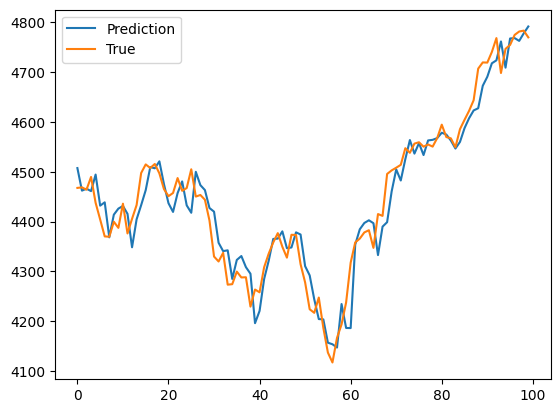

In [ ]:
import matplotlib.pyplot as plt
plt.plot(un_norm_pred[-100:], label="Prediction")
plt.plot(un_norm_test[-100:], label="True")
plt.legend()

In [ ]:
pred2 = un_norm_test[:-1]
true2 = un_norm_test[1:]

In [ ]:
np.sqrt(mean_squared_error(pred2, true2))

46.04679745791304

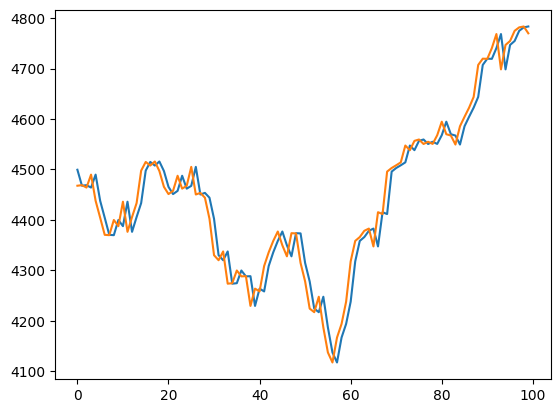

In [ ]:
import matplotlib.pyplot as plt
plt.plot(pred2[-100:], label="Prediction")
plt.plot(true2[-100:], label="True")